In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)



In [50]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Windows 10 Pro\OneDrive\Desktop\RETAILPULSE\venv\Scripts\python.exe
3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]


In [78]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.etl.ingest import load_data

df = load_data("../data/raw/online_retail_II.csv")

In [52]:
df.head()
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [53]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1067371
Columns : 8


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [55]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().sum()/len(df)*100,2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [56]:
df[df["Quantity"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [57]:
df.describe()
df.describe(include="object")


C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_12912\416577622.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330


In [58]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [59]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [60]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 34335


In [61]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [62]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Invoice : 53628
StockCode : 5305
Description : 5698
Quantity : 1057
InvoiceDate : 47635
Price : 2807
Customer ID : 5942
Country : 43


In [63]:
df[df["Quantity"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [64]:
df[df["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [65]:
cancelled = df["Invoice"].astype(str).str.startswith("C")

cancelled.value_counts()

Invoice
False    1047877
True       19494
Name: count, dtype: int64

In [66]:
df["Country"].value_counts()

Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               3189
Belgium                   3123
Portugal                  2620
Australia                 1913
Channel Islands           1664
Italy                     1534
Norway                    1455
Sweden                    1364
Cyprus                    1176
Finland                   1049
Austria                    938
Denmark                    817
Unspecified                756
Greece                     663
Japan                      582
USA                        535
Poland                     535
United Arab Emirates       500
Israel                     371
Hong Kong                  364
Singapore                  346
Malta                      299
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        169


In [67]:
df["Country"].value_counts().head(10)

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

In [68]:
df["Description"].value_counts().head(20)

Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
JUMBO SHOPPER VINTAGE RED PAISLEY     2297
60 TEATIME FAIRY CAKE CASES           2271
PAPER CHAIN KIT 50'S CHRISTMAS        2215
LUNCH BAG SPACEBOY DESIGN             2206
REX CASH+CARRY JUMBO SHOPPER          2199
HOME BUILDING BLOCK WORD              2192
WOODEN FRAME ANTIQUE WHITE            2189
LUNCH BAG CARS BLUE                   2184
NATURAL SLATE HEART CHALKBOARD        2151
BAKING SET 9 PIECE RETROSPOT          2150
POSTAGE                               2115
Name: count, dtype: int64

In [69]:
df["Invoice"].nunique()

53628

In [70]:
df["Customer ID"].nunique()

5942

In [71]:
df.memory_usage(deep=True)

Index               132
Invoice        58724905
StockCode      57757750
Description    80585650
Quantity        8538968
InvoiceDate    72581228
Price           8538968
Customer ID     8538968
Country        66618497
dtype: int64

In [72]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 34335


In [73]:
df[df["Quantity"] == 0]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [74]:
df[df["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [75]:
df[df["Invoice"].str.startswith("C")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [76]:
df["Invoice"].astype(str).str.startswith("C").sum()

np.int64(19494)

In [77]:
print("Invoices :", df["Invoice"].nunique())
print("Products :", df["StockCode"].nunique())
print("Customers :", df["Customer ID"].nunique())
print("Countries :", df["Country"].nunique())

Invoices : 53628
Products : 5305
Customers : 5942
Countries : 43


In [79]:
from src.etl.validator import validate_data

report = validate_data(df)

report

{'rows': 1067371,
 'columns': 8,
 'duplicate_rows': 34335,
 'missing_values': {'Invoice': 0,
  'StockCode': 0,
  'Description': 4382,
  'Quantity': 0,
  'InvoiceDate': 0,
  'Price': 0,
  'Customer ID': 243007,
  'Country': 0},
 'negative_quantity': 22950,
 'zero_quantity': 0,
 'negative_price': 5,
 'zero_price': 6202,
 'cancelled_orders': 19494,
 'unique_customers': 5942,
 'unique_products': 5305,
 'unique_invoices': 53628,
 'countries': 43}

In [80]:
from src.etl.cleaner import clean_data

clean_df = clean_data(df)

clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False


In [81]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 1033031 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   Invoice       1033031 non-null  str           
 1   StockCode     1033031 non-null  str           
 2   Description   1028756 non-null  str           
 3   Quantity      1033031 non-null  int64         
 4   InvoiceDate   1033031 non-null  datetime64[us]
 5   Price         1033031 non-null  float64       
 6   Customer ID   797885 non-null   float64       
 7   Country       1033031 non-null  str           
 8   is_cancelled  1033031 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 71.9 MB


In [82]:
from src.etl.feature_engineering import create_features

feature_df = create_features(clean_df)

feature_df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,TotalPrice,Year,Month,Day,DayOfWeek,Hour,Quarter,IsWeekend,InvoiceMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,1,Tuesday,7,4,False,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,1,Tuesday,7,4,False,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,1,Tuesday,7,4,False,2009-12


In [83]:
feature_df.info()

<class 'pandas.DataFrame'>
Index: 1033031 entries, 0 to 1067370
Data columns (total 18 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   Invoice       1033031 non-null  str           
 1   StockCode     1033031 non-null  str           
 2   Description   1028756 non-null  str           
 3   Quantity      1033031 non-null  int64         
 4   InvoiceDate   1033031 non-null  datetime64[us]
 5   Price         1033031 non-null  float64       
 6   Customer ID   797885 non-null   float64       
 7   Country       1033031 non-null  str           
 8   is_cancelled  1033031 non-null  bool          
 9   TotalPrice    1033031 non-null  float64       
 10  Year          1033031 non-null  int32         
 11  Month         1033031 non-null  int32         
 12  Day           1033031 non-null  int32         
 13  DayOfWeek     1033031 non-null  str           
 14  Hour          1033031 non-null  int32         
 15  Quarter       

In [84]:
from src.etl.loader import save_processed_data

save_processed_data(feature_df)

Processed dataset saved to: data/processed/online_retail_processed.csv


In [85]:
save_processed_data(feature_df)

Processed dataset saved to: data/processed/online_retail_processed.csv


In [86]:
from pathlib import Path

print(Path.cwd())


c:\Users\Windows 10 Pro\OneDrive\Desktop\RETAILPULSE\notebooks


In [87]:
import importlib
import src.etl.loader as loader

importlib.reload(loader)

<module 'src.etl.loader' from 'c:\\Users\\Windows 10 Pro\\OneDrive\\Desktop\\RETAILPULSE\\src\\etl\\loader.py'>

In [88]:
loader.save_processed_data(feature_df)


Project Root : C:\Users\Windows 10 Pro\OneDrive\Desktop\RETAILPULSE
Saved To     : C:\Users\Windows 10 Pro\OneDrive\Desktop\RETAILPULSE\data\processed\online_retail_processed.csv


In [2]:
import pandas as pd

import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.etl.ingest import load_data

from src.analytics import sales_analysis

from src.analytics import visualization

In [4]:
df = load_data("../data/processed/online_retail_processed.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,TotalPrice,Year,Month,Day,DayOfWeek,Hour,Quarter,IsWeekend,InvoiceMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,1,Tuesday,7,4,False,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,1,Tuesday,7,4,False,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,1,Tuesday,7,4,False,2009-12


In [5]:
monthly = sales_analysis.monthly_sales(df)

monthly

,InvoiceMonth,Revenue
0,2009-12,796648.500
1,2010-01,622479.502
2,2010-02,531265.366
3,2010-03,763247.241
4,2010-04,641521.052
5,2010-05,613270.720
6,2010-06,677073.870
7,2010-07,617365.480
8,2010-08,654774.390
9,2010-09,851105.961


In [6]:
fig = visualization.line_chart(
    monthly,
    "InvoiceMonth",
    "Revenue",
    "Monthly Revenue"
)

fig.show()

In [9]:
hourly = sales_analysis.hourly_sales(df)

visualization.bar_chart(
    hourly,
    "Hour",
    "Revenue",
    "Hourly Sales"
).show()

In [10]:
weekend = sales_analysis.weekday_vs_weekend(df)

visualization.pie_chart(
    weekend,
    "IsWeekend",
    "Revenue",
    "Weekend vs Weekday Revenue"
).show()

In [11]:


import pandas as pd

from src.etl.ingest import load_data

import src.segmentation.rfm as rfm

In [13]:
df = load_data("../data/processed/online_retail_processed.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,TotalPrice,Year,Month,Day,DayOfWeek,Hour,Quarter,IsWeekend,InvoiceMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,1,Tuesday,7,4,False,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,1,Tuesday,7,4,False,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,1,Tuesday,7,4,False,2009-12


In [14]:
df.shape

(1033031, 18)

In [16]:
rfm_df = rfm.create_rfm(df)

rfm_df.head()

rfm.head()

TypeError: can only concatenate str (not "datetime.timedelta") to str

In [17]:
df.dtypes

Invoice             str
StockCode           str
Description         str
Quantity          int64
InvoiceDate         str
Price           float64
Customer ID     float64
Country             str
is_cancelled       bool
TotalPrice      float64
Year              int64
Month             int64
Day               int64
DayOfWeek           str
Hour              int64
Quarter           int64
IsWeekend          bool
InvoiceMonth        str
dtype: object

In [18]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [20]:
rfm_df = rfm.create_rfm(df)

rfm_df.head()


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [22]:
rfm_df.shape

(5881, 4)

In [23]:
summary = rfm.customer_summary(rfm_df)

summary


{'Total Customers': 5881,
 'Average Recency': np.float64(201.46),
 'Average Frequency': np.float64(6.29),
 'Average Monetary': np.float64(2954.4),
 'Highest Spending': np.float64(580987.04),
 'Lowest Spending': np.float64(0.0)}

In [24]:
rfm_df = rfm.add_rfm_scores(rfm_df)

rfm_df.head()



,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,4921.53,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212


In [26]:
top_customers(rfm_df)

NameError: name 'top_customers' is not defined

In [27]:
rfm.top_customers(rfm_df)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
5695,18102.0,1,145,580987.04,5,5,5,555
2279,14646.0,2,152,528602.52,5,5,5,555
1791,14156.0,10,156,313437.62,5,5,5,555
2541,14911.0,1,398,291420.81,5,5,5,555
5053,17450.0,8,51,244784.25,5,5,5,555
1332,13694.0,4,143,195640.69,5,5,5,555
5112,17511.0,3,60,172132.87,5,5,5,555
4064,16446.0,1,2,168472.50,5,2,5,525
4298,16684.0,4,55,147142.77,5,5,5,555
68,12415.0,24,28,144458.37,4,5,5,455


In [28]:
rfm.bottom_customers(rfm_df)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
2458,14827.0,665,1,0.00,1,1,1,111
1739,14103.0,665,1,0.00,1,1,1,111
904,13256.0,14,1,0.00,5,1,1,511
1731,14095.0,723,1,2.95,1,1,1,111
1425,13788.0,505,1,3.75,1,1,1,111
4351,16738.0,298,1,3.75,2,2,1,221
2423,14792.0,64,1,6.20,3,1,1,311
3535,15913.0,534,1,6.30,1,1,1,111
2667,15040.0,542,1,7.49,1,1,1,111
5708,18115.0,698,1,9.70,1,2,1,121


In [30]:
# Replace rfm.describe() with:
rfm_df.describe()

# show the earlier summary dict as a Series/table
pd.Series(summary)

Total Customers        5881.00
Average Recency         201.46
Average Frequency         6.29
Average Monetary       2954.40
Highest Spending     580987.04
Lowest Spending           0.00
dtype: float64

In [32]:
import src.segmentation.clustering as clustering

In [33]:
scaled_data, scaler = clustering.scale_features(rfm_df)

scaled_data.head()

,Recency,Frequency,Monetary
0,0.594598,0.439049,5.167745
1,-0.952264,0.131635,0.136265
2,-0.603743,-0.098925,-0.064768
3,-0.871102,-0.175779,0.102126
4,0.518209,-0.406339,-0.181489


In [34]:
scaled_data.describe()

,Recency,Frequency,Monetary
count,5.881000e+03,5.881000e+03,5.881000e+03
mean,-4.953622e-17,-2.778861e-17,1.208201e-18
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.570384e-01,-4.063394e-01,-2.046534e-01
25%,-8.376818e-01,-4.063394e-01,-1.809697e-01
50%,-5.034832e-01,-2.526325e-01,-1.446926e-01
75%,8.524080e-01,5.478146e-02,-4.895204e-02
max,2.566369e+00,3.010449e+01,4.004079e+01


In [35]:
inertia = clustering.elbow_method(scaled_data)
inertia



[17642.999999999996,
 12115.928016370191,
 7133.657212146632,
 5160.535952738979,
 3903.454590493534,
 3296.511443934495,
 2747.585170487956,
 2268.2217326180603,
 1923.7573282917492,
 1723.723652048819]

In [36]:
import matplotlib.pyplot as plt

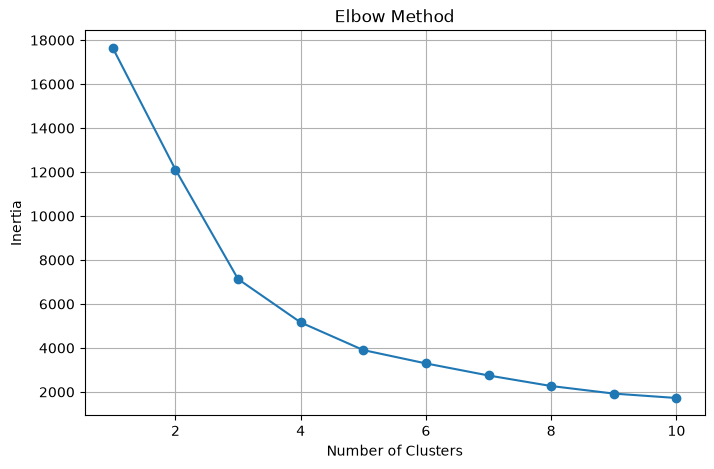

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [38]:
model, clusters = clustering.train_kmeans(
    scaled_data,
    n_clusters=4
)

In [39]:
clusters

array([1, 1, 1, ..., 3, 3, 1], shape=(5881,), dtype=int32)

In [40]:
rfm_cluster = clustering.assign_clusters(
    rfm_df,
    clusters
)

rfm_cluster.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster
0,12346.0,326,12,77556.46,2,5,5,255,1
1,12347.0,2,8,4921.53,5,4,5,545,1
2,12348.0,75,5,2019.40,3,4,4,344,1
3,12349.0,19,4,4428.69,5,3,5,535,1
4,12350.0,310,1,334.40,2,1,2,212,3


In [41]:
rfm_cluster["Cluster"].value_counts()

Cluster
1    3839
3    2000
0      38
2       4
Name: count, dtype: int64

In [42]:
rfm_cluster.groupby("Cluster")[
    ["Recency","Frequency","Monetary"]
].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,24.263158,100.157895,77728.265579
1,67.040636,7.266476,2920.319162
2,3.500000,212.750000,428611.997500
3,463.234000,2.211000,747.788461


In [43]:
rfm_cluster.head(20)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster
0,12346.0,326,12,77556.46,2,5,5,255,1
1,12347.0,2,8,4921.53,5,4,5,545,1
2,12348.0,75,5,2019.40,3,4,4,344,1
3,12349.0,19,4,4428.69,5,3,5,535,1
4,12350.0,310,1,334.40,2,1,2,212,3
5,12351.0,375,1,300.93,2,1,2,212,3
6,12352.0,36,10,2849.84,4,5,4,454,1
7,12353.0,204,2,406.76,2,2,2,222,1
8,12354.0,232,1,1079.40,2,1,3,213,1
9,12355.0,214,2,947.61,2,2,3,223,1


In [47]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import silhouette_score, davies_bouldin_score
# `plot_clusters` and `plot_silhouette` are not available from src.segmentation.visualization,
# so remove that import or import equivalent plotting helpers from a module that provides them.

In [48]:
score = silhouette_score(scaled_data, clusters)

print(score)

0.5913546614905065


In [49]:
cluster_summary = rfm_cluster.groupby("Cluster")[
    ["Recency","Frequency","Monetary"]
].mean()

summary

{'Total Customers': 5881,
 'Average Recency': np.float64(201.46),
 'Average Frequency': np.float64(6.29),
 'Average Monetary': np.float64(2954.4),
 'Highest Spending': np.float64(580987.04),
 'Lowest Spending': np.float64(0.0)}

In [50]:
def plot_cluster_distribution(rfm_cluster):
    """Plot the distribution of customers across clusters"""
    cluster_counts = rfm_cluster["Cluster"].value_counts().sort_index()
    
    fig = px.bar(
        x=cluster_counts.index,
        y=cluster_counts.values,
        labels={"x": "Cluster", "y": "Number of Customers"},
        title="Cluster Distribution"
    )
    
    return fig

In [52]:
def plot_recency_frequency(rfm_cluster):
    fig = px.scatter(
        rfm_cluster,
        x="Recency",
        y="Frequency",
        color="Cluster",
        size="Monetary",
        hover_data=["Customer ID", "Monetary", "RFM_Score"],
        title="Recency vs Frequency (size=Monetary)",
        labels={"Recency": "Recency (days)", "Frequency": "Frequency", "Monetary": "Monetary"}
    )
    return fig

import plotly.express as px

def plot_recency_frequency(rfm_cluster):
    fig = px.scatter(
        rfm_cluster,
        x="Recency",
        y="Frequency",
        color="Cluster",
        size="Monetary",
        hover_data=["Customer ID", "Monetary", "RFM_Score"],
        title="Recency vs Frequency (size=Monetary)",
        labels={"Recency": "Recency (days)", "Frequency": "Frequency", "Monetary": "Monetary"}
    )
    return fig

plot_recency_frequency(rfm_cluster).show()

In [53]:
def plot_frequency_monetary(rfm_cluster):
    fig = px.scatter(
        rfm_cluster,
        x="Frequency",
        y="Monetary",
        color="Cluster",
        size="Frequency",
        hover_data=["Customer ID", "Recency", "RFM_Score"],
        title="Frequency vs Monetary (size=Frequency)",
        labels={"Frequency": "Frequency", "Monetary": "Monetary"}
    )
    return fig

# call the function
plot_frequency_monetary(rfm_cluster).show()


In [54]:
def plot_recency_monetary(rfm_cluster):
    fig = px.scatter(
        rfm_cluster,
        x="Recency",
        y="Monetary",
        color="Cluster",
        size="Frequency",
        hover_data=["Customer ID", "Frequency", "RFM_Score"],
        title="Recency vs Monetary (size=Frequency)",
        labels={"Recency": "Recency (days)", "Monetary": "Monetary"}
    )
    return fig

plot_recency_monetary(rfm_cluster).show()

In [55]:
cluster_names = {
    0: "Champions",
    1: "Loyal Customers",
    2: "Potential Customers",
    3: "At Risk"
}

rfm_cluster["Segment"] = (
    rfm_cluster["Cluster"]
    .map(cluster_names)
)

rfm_cluster.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
0,12346.0,326,12,77556.46,2,5,5,255,1,Loyal Customers
1,12347.0,2,8,4921.53,5,4,5,545,1,Loyal Customers
2,12348.0,75,5,2019.40,3,4,4,344,1,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,535,1,Loyal Customers
4,12350.0,310,1,334.40,2,1,2,212,3,At Risk


In [56]:
rfm_cluster["Segment"].value_counts()

Segment
Loyal Customers        3839
At Risk                2000
Champions                38
Potential Customers       4
Name: count, dtype: int64

In [57]:
rfm_cluster.groupby("Segment")[
    ["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,463.234000,2.211000,747.788461
Champions,24.263158,100.157895,77728.265579
Loyal Customers,67.040636,7.266476,2920.319162
Potential Customers,3.500000,212.750000,428611.997500


In [61]:
from pathlib import Path

# Find RetailPulse root directory
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "RETAILPULSE":
    PROJECT_ROOT = PROJECT_ROOT.parent

output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

rfm_cluster.to_csv(
    output_dir / "customer_segments.csv",
    index=False
)

print(f"Saved to: {output_dir / 'customer_segments.csv'}")

Saved to: c:\Users\Windows 10 Pro\OneDrive\Desktop\RETAILPULSE\data\processed\customer_segments.csv
